In [1]:
# ============================================================
# BLOCK 1
# ENVIRONMENT + DRIVE + REPRODUCIBILITY + KAGGLE SETUP
# ============================================================

# ---------- Google Drive ----------
from google.colab import drive, files
drive.mount('/content/drive')

# ---------- Core Libraries ----------
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd

import tensorflow as tf

warnings.filterwarnings("ignore")

# ---------- Reproducibility ----------
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ---------- Save Paths ----------
SAVE_ROOT = "/content/drive/MyDrive/AI_HYBRID_EMPC_V2"

os.makedirs(SAVE_ROOT, exist_ok=True)

MODEL_DIR = os.path.join(SAVE_ROOT, "models")
DATA_DIR  = os.path.join(SAVE_ROOT, "datasets")
FIG_DIR   = os.path.join(SAVE_ROOT, "figures")
KPI_DIR   = os.path.join(SAVE_ROOT, "kpi")

for folder in [MODEL_DIR, DATA_DIR, FIG_DIR, KPI_DIR]:
    os.makedirs(folder, exist_ok=True)

print("="*60)
print("PROJECT ROOT :", SAVE_ROOT)
print("MODEL DIR    :", MODEL_DIR)
print("DATA DIR     :", DATA_DIR)
print("FIGURE DIR   :", FIG_DIR)
print("KPI DIR      :", KPI_DIR)
print("="*60)

# ---------- Upload Kaggle API ----------
print("\nUpload kaggle.json now...\n")

uploaded = files.upload()

# ---------- Kaggle Setup ----------
os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("\nKaggle API configured successfully.")

Mounted at /content/drive
PROJECT ROOT : /content/drive/MyDrive/AI_HYBRID_EMPC_V2
MODEL DIR    : /content/drive/MyDrive/AI_HYBRID_EMPC_V2/models
DATA DIR     : /content/drive/MyDrive/AI_HYBRID_EMPC_V2/datasets
FIGURE DIR   : /content/drive/MyDrive/AI_HYBRID_EMPC_V2/figures
KPI DIR      : /content/drive/MyDrive/AI_HYBRID_EMPC_V2/kpi

Upload kaggle.json now...



Saving kaggle.json to kaggle.json

Kaggle API configured successfully.


In [2]:
# ============================
# BLOCK 2 — KAGGLE SETUP + DATASET DOWNLOAD
# ============================

import os
import shutil

# ----------------------------
# 1. Ensure Kaggle config directory exists
# ----------------------------
KAGGLE_DIR = "/root/.kaggle"
os.makedirs(KAGGLE_DIR, exist_ok=True)

# ----------------------------
# 2. Move kaggle.json safely (uploaded in BLOCK 1)
# ----------------------------
if os.path.exists("kaggle.json"):
    shutil.copy("kaggle.json", f"{KAGGLE_DIR}/kaggle.json")
    os.chmod(f"{KAGGLE_DIR}/kaggle.json", 0o600)
    print("✅ kaggle.json configured")
else:
    print("❌ kaggle.json not found. Upload it using files.upload() first.")

# ----------------------------
# 3. Install Kaggle CLI (safe re-run)
# ----------------------------
!pip -q install kaggle

# ----------------------------
# 4. Define datasets (your exact pipeline)
# ----------------------------
datasets = {
    "env": "mertkont/energy-and-environment-data",
    "cons": "littlebaldturtle/electricity-consumption",
    "load": "saurabhshahane/electricity-load-forecasting",
    "dc": "programmer3/data-center-cold-source-control-dataset"
}

# ----------------------------
# 5. Download datasets (idempotent-safe)
# ----------------------------
for name, ds in datasets.items():
    zip_name = ds.split("/")[-1] + ".zip"

    if not os.path.exists(zip_name):
        print(f"⬇ Downloading: {ds}")
        !kaggle datasets download -d {ds} -q
    else:
        print(f"✔ Already downloaded: {zip_name}")

# ----------------------------
# 6. Extract datasets safely
# ----------------------------
import zipfile

extract_map = {
    "energy-and-environment-data.zip": "env",
    "electricity-consumption.zip": "cons",
    "electricity-load-forecasting.zip": "load",
    "data-center-cold-source-control-dataset.zip": "dc"
}

for zip_file, folder in extract_map.items():
    if os.path.exists(zip_file):
        print(f"📦 Extracting {zip_file} → {folder}/")

        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(folder)

    else:
        print(f"⚠ Missing zip: {zip_file}")

# ----------------------------
# 7. Verify structure
# ----------------------------
print("\n========== DATASET STRUCTURE CHECK ==========\n")

for folder in ["env", "cons", "load", "dc"]:
    if os.path.exists(folder):
        files_found = len(os.listdir(folder))
        print(f"{folder}/ → {files_found} items")
    else:
        print(f"{folder}/ → NOT FOUND")

✅ kaggle.json configured
⬇ Downloading: mertkont/energy-and-environment-data
Dataset URL: https://www.kaggle.com/datasets/mertkont/energy-and-environment-data
License(s): MIT
⬇ Downloading: littlebaldturtle/electricity-consumption
Dataset URL: https://www.kaggle.com/datasets/littlebaldturtle/electricity-consumption
License(s): unknown
⬇ Downloading: saurabhshahane/electricity-load-forecasting
Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/electricity-load-forecasting
License(s): Attribution 4.0 International (CC BY 4.0)
⬇ Downloading: programmer3/data-center-cold-source-control-dataset
Dataset URL: https://www.kaggle.com/datasets/programmer3/data-center-cold-source-control-dataset
License(s): CC0-1.0
📦 Extracting energy-and-environment-data.zip → env/
📦 Extracting electricity-consumption.zip → cons/
📦 Extracting electricity-load-forecasting.zip → load/
📦 Extracting data-center-cold-source-control-dataset.zip → dc/

========== DATASET STRUCTURE CHECK ==========

env/ → 1 it

In [3]:
# ============================
# BLOCK 3 — ROBUST DATA LOADING + CLEANING
# ============================

import os
import glob
import numpy as np
import pandas as pd

# ----------------------------
# 1. SAFE CSV LOADER (handles messy Kaggle datasets)
# ----------------------------
def load_csv_files(root_folder):

    all_files = glob.glob(root_folder + "/**/*.csv", recursive=True)

    dfs = []

    for file in all_files:
        try:
            df = pd.read_csv(file, low_memory=False, encoding_errors="ignore")

            # Drop fully empty columns early
            df = df.dropna(axis=1, how="all")

            # Detect time columns
            time_cols = [
                c for c in df.columns
                if any(k in c.lower() for k in ["time", "date", "timestamp"])
            ]

            # Convert numeric safely
            for col in df.columns:
                if col not in time_cols:
                    df[col] = pd.to_numeric(df[col], errors="coerce")

            # Forward fill then backfill (better than pure ffill)
            df = df.ffill().bfill()

            # Drop rows still fully NaN
            df = df.dropna(how="all")

            # Sort if time exists
            if len(time_cols) > 0:
                df = df.sort_values(time_cols[0])

            # Keep only useful tables
            if df.shape[0] > 20 and df.shape[1] > 0:
                dfs.append(df)

        except Exception as e:
            print(f"⚠ Skipped file: {file} | Error: {str(e)[:80]}")

    return dfs


# ----------------------------
# 2. NORMALIZER (FIT PER DATASET — NOT GLOBAL LEAKAGE)
# ----------------------------
def normalize_dfs(dfs):

    out = []

    for df in dfs:

        numeric = df.select_dtypes(include=[np.number]).copy()

        if numeric.shape[1] == 0:
            continue

        # stable normalization (no sklearn leakage across datasets)
        mu = numeric.mean()
        sigma = numeric.std().replace(0, 1e-8)

        numeric = (numeric - mu) / sigma

        out.append(numeric.fillna(0))

    return out


# ----------------------------
# 3. MERGE SAFELY
# ----------------------------
def merge_dfs(dfs):

    if dfs is None or len(dfs) == 0:
        return None

    return pd.concat(dfs, ignore_index=True)


# ----------------------------
# 4. LOAD ALL KAGGLE SOURCES
# ----------------------------
env_dfs  = normalize_dfs(load_csv_files("/content/env"))
cons_dfs = normalize_dfs(load_csv_files("/content/cons"))
load_dfs = normalize_dfs(load_csv_files("/content/load"))
dc_dfs   = normalize_dfs(load_csv_files("/content/dc"))

env  = merge_dfs(env_dfs)
cons = merge_dfs(cons_dfs)
load = merge_dfs(load_dfs)
dc   = merge_dfs(dc_dfs)

# ----------------------------
# 5. FINAL DATASET BUILD
# ----------------------------
data_frames = [df for df in [env, cons, load, dc] if df is not None]

data = pd.concat(data_frames, ignore_index=True)

# final safety cleanup
data = data.replace([np.inf, -np.inf], np.nan).fillna(0)
data = data.select_dtypes(include=[np.number])

# ----------------------------
# 6. VALIDATION CHECKS
# ----------------------------
print("\n========== DATA PIPELINE STATUS ==========\n")

print("Env shape :", None if env is None else env.shape)
print("Cons shape:", None if cons is None else cons.shape)
print("Load shape:", None if load is None else load.shape)
print("DC shape  :", None if dc is None else dc.shape)

print("\nFINAL COMBINED DATA SHAPE:", data.shape)

# HARD FAIL SAFETY
if data.shape[0] < 50:
    raise ValueError("❌ Dataset too small — check Kaggle extraction or CSV parsing")


========== DATA PIPELINE STATUS ==========

Env shape : (9695, 9)
Cons shape: (144, 1)
Load shape: (88200, 17)
DC shape  : (3498, 11)

FINAL COMBINED DATA SHAPE: (101537, 38)


In [4]:
# ============================
# BLOCK 4 — SEQUENCE ENGINE (LSTM PREP)
# ============================

import numpy as np

SEQ_LEN = 24
PRED_LEN = 6
zones = 5

# ----------------------------
# 1. FINAL SAFE NUMERIC MATRIX
# ----------------------------
data_matrix = data.values.astype(np.float32)

# HARD SAFETY: remove NaNs / inf
data_matrix = np.nan_to_num(data_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print("✔ Clean matrix shape:", data_matrix.shape)

# ----------------------------
# 2. SEQUENCE BUILDER (OPTIMIZED, NO LIST GROWTH OVERHEAD)
# ----------------------------
def create_sequences(matrix, seq_len, pred_len):

    X = []
    y = []

    max_i = len(matrix) - seq_len - pred_len

    if max_i <= 0:
        raise ValueError("❌ Not enough data for sequence generation")

    for i in range(max_i):

        x_seq = matrix[i : i + seq_len]
        y_seq = matrix[i + seq_len : i + seq_len + pred_len]

        # ----------------------------
        # stability weighting (prevents flat learning)
        # ----------------------------
        weight = np.linspace(0.6, 1.0, seq_len).reshape(-1, 1)
        x_seq = x_seq * weight

        X.append(x_seq)
        y.append(y_seq)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y


# ----------------------------
# 3. BUILD SEQUENCES
# ----------------------------
X, y = create_sequences(data_matrix, SEQ_LEN, PRED_LEN)

print("\n========== SEQUENCE OUTPUT ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ----------------------------
# 4. TRAIN / VALID SPLIT (NO SHUFFLE — TIME SERIES SAFE)
# ----------------------------
split = int(len(X) * 0.8)

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("\n========== SPLIT INFO ==========")
print("Train X:", X_train.shape)
print("Val X  :", X_val.shape)

# ----------------------------
# 5. FINAL SANITY CHECK
# ----------------------------
assert X_train.shape[0] > 100, "❌ Not enough training samples"
assert X_train.shape[1:] == (SEQ_LEN, data.shape[1]), "❌ Shape mismatch"

✔ Clean matrix shape: (101537, 38)

========== SEQUENCE OUTPUT ==========
X shape: (101507, 24, 38)
y shape: (101507, 6, 38)

========== SPLIT INFO ==========
Train X: (81205, 24, 38)
Val X  : (20302, 24, 38)


In [5]:
# ============================
# BLOCK 5 — BI-LSTM FORECASTING MODEL
# ============================

import tensorflow as tf
from tensorflow.keras import layers
import os

tf.random.set_seed(42)

SAVE_ROOT = "/content/drive/MyDrive/EMPC_FINAL_SYSTEM"
os.makedirs(SAVE_ROOT, exist_ok=True)

# ----------------------------
# 1. MODEL ARCHITECTURE (BI-LSTM)
# ----------------------------
def build_bilstm(seq_len, features, pred_len):

    inp = tf.keras.Input(shape=(seq_len, features))

    # ----------------------------
    # Encoder Stack
    # ----------------------------
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    )(inp)

    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False)
    )(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    # ----------------------------
    # Output Projection
    # ----------------------------
    x = layers.Dense(pred_len * features)(x)
    out = layers.Reshape((pred_len, features))(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber()  # more stable than MSE for noisy energy data
    )

    return model


# ----------------------------
# 2. BUILD MODEL
# ----------------------------
features = X_train.shape[-1]

model = build_bilstm(SEQ_LEN, features, PRED_LEN)

model.summary()

# ----------------------------
# 3. TRAINING (STABLE CONFIG)
# ----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    shuffle=False,  # CRITICAL for time series
    verbose=1
)

# ----------------------------
# 4. SAVE MODEL (FOR EMPC INFERENCE)
# ----------------------------
MODEL_PATH = SAVE_ROOT + "/bilstm_forecaster.keras"
model.save(MODEL_PATH)

print("\n✅ MODEL SAVED AT:", MODEL_PATH)

# ----------------------------
# 5. QUICK VALIDATION PREDICTION CHECK
# ----------------------------
test_sample = X_val[:1]
pred = model.predict(test_sample, verbose=0)

print("\n✔ Prediction shape:", pred.shape)
print("✔ Expected shape:", (1, PRED_LEN, features))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 38)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       171,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 228)            │        29,412 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 38)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 381,284 (1.45 MB)

 Trainable params: 381,284 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 0.0579 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 2/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0411 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 3/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0366 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 4/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0343 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 5/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0327 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 6/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0321 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 7/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0313 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 8/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0308 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 9/10
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0305 - val_loss: 0.022

In [7]:
# ============================
# BLOCK 6 — FORECAST → DISTURBANCE INTERFACE
# ============================

import numpy as np
from tensorflow.keras.models import load_model

# ----------------------------
# 1. LOAD TRAINED MODEL
# ----------------------------
MODEL_PATH = SAVE_ROOT + "/bilstm_forecaster.keras"

lstm = load_model(MODEL_PATH)

print("✅ LSTM LOADED FROM DISK")

# ----------------------------
# 2. GLOBAL CONFIG
# ----------------------------
SEQ_LEN = 24
PRED_LEN = 6
zones = 5

# ----------------------------
# 3. FEATURE REDUCTION MAP
#    (38-dim → 5-zone control signal)
# ----------------------------
def map_to_zones(signal_vector, zones=5):

    signal_vector = np.array(signal_vector)

    # robust aggregation (prevents noise domination)
    abs_signal = np.abs(signal_vector)

    idx = np.linspace(0, len(abs_signal) - 1, zones).astype(int)

    zone_signal = abs_signal[idx]

    # normalize to stable actuator range
    zone_signal = zone_signal / (np.max(zone_signal) + 1e-8)

    return np.clip(zone_signal, 0.0, 2.0)

# ----------------------------
# 4. LSTM FORECAST WRAPPER
# ----------------------------
def forecast_disturbance(seq):

    seq = np.array(seq, dtype=np.float32)

    # safety: enforce sequence length
    if seq.shape[0] != SEQ_LEN:
        seq = seq[-SEQ_LEN:]

    seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)

    # LSTM prediction
    pred = lstm.predict(seq[np.newaxis, ...], verbose=0)[0]

    # collapse time horizon (6-step → single influence vector)
    temporal_mean = np.mean(pred, axis=0)

    # convert to zone disturbances
    dist = map_to_zones(temporal_mean, zones)

    return dist

# ----------------------------
# 5. QUICK SANITY TEST
# ----------------------------
test_seq = X_val[0]

dist = forecast_disturbance(test_seq)

print("\n========== DISTURBANCE TEST ==========")
print("Shape:", dist.shape)
print("Values:", dist)

✅ LSTM LOADED FROM DISK

========== DISTURBANCE TEST ==========
Shape: (5,)
Values: [0.00802325 0.00128114 0.9999988  0.00366638 0.00169778]


In [8]:
# ============================
# BLOCK 7 — SYSTEM PHYSICS CORE
# ============================

import numpy as np

np.random.seed(42)

# ----------------------------
# 1. SYSTEM CONFIGURATION
# ----------------------------
zones = 5
T_ref = 22.0

# ----------------------------
# 2. HETEROGENEOUS HARDWARE MODEL
# ----------------------------
hardware_efficiency = np.array([1.35, 1.00, 0.65, 0.90, 1.50])
hardware_inertia    = np.array([1.20, 1.00, 1.80, 1.10, 1.40])
hardware_latency    = np.array([0.20, 0.55, 0.95, 0.45, 0.25])

# failure probabilities per zone
hardware_failure_p  = np.array([0.02, 0.05, 0.10, 0.04, 0.03])

# ----------------------------
# 3. HARDWARE MASK (DYNAMIC FAILURES)
# ----------------------------
def hardware_mask():
    return (np.random.rand(zones) > hardware_failure_p).astype(float)

# ----------------------------
# 4. LYAPUNOV FUNCTION (STABILITY ENERGY)
# ----------------------------
def lyapunov(T):
    return np.sum((T - T_ref) ** 2)

# ----------------------------
# 5. ADVERSARIAL ATTACK MODEL (FDI + CYBER-PHYSICAL)
# ----------------------------
def generate_attack(t, state=None):

    attack = np.zeros(zones)

    # sustained attack window (simulates persistent intrusion)
    if 30 <= t <= 120:
        attack += np.random.uniform(1.5, 3.5, zones)

    # stochastic burst attack (spoofed telemetry spikes)
    if np.random.rand() < 0.06:
        attack += np.random.uniform(0.5, 2.2, zones)

    # state-dependent amplification (feedback instability attack)
    if state is not None:
        instability = np.linalg.norm(state - T_ref)
        attack += 0.15 * instability

    return attack

# ----------------------------
# 6. THERMAL DYNAMICS MODEL (REALISTIC + COUPLED)
# ----------------------------
def thermal_dynamics(T, u, workload, attack):

    mask = hardware_mask()
    noise = np.random.normal(0, 0.025, zones)

    # effective control after hardware degradation
    u_eff = u * hardware_efficiency * mask

    # nonlinear heat evolution model
    T_next = (
        0.86 * T
        - 1.40 * u_eff
        + 1.25 * workload * hardware_inertia
        + attack * hardware_latency
        + noise
    )

    return T_next

# ----------------------------
# 7. SYSTEM SANITY TEST
# ----------------------------
T_test = np.ones(zones) * 25.0
u_test = np.array([0.5]*zones)
w_test = np.random.uniform(0.2, 0.8, zones)
a_test = generate_attack(50, T_test)

T_next = thermal_dynamics(T_test, u_test, w_test, a_test)

print("\n========== PHYSICS TEST ==========")
print("Next Temperature:", T_next)
print("Lyapunov:", lyapunov(T_next))


========== PHYSICS TEST ==========
Next Temperature: [22.17479823 24.24012823 27.31018963 23.61830611 22.13162355]
Lyapunov: 35.88308219157321


In [14]:
# ============================
# BLOCK 8 — CONTROL SYSTEMS CORE (STRICT PAPER ALIGNMENT)
# ============================

import cvxpy as cp
import numpy as np

# ----------------------------
# GLOBAL REFERENCE & MATRICES (Section IV.A)
# ----------------------------
T_ref = 22.0
zones = 5

# Heterogeneous diagonal system matrices (Eq. 1 parameters)
A_mat = np.array([0.88, 0.85, 0.82, 0.86, 0.84])
B_mat = np.array([-1.5, -1.2, -1.0, -1.3, -1.1])

# ============================
# 1. PID CONTROLLER (RAW BASELINE)
# ============================
def pid_controller(T, integ, prev_error):
    Kp, Ki, Kd = 0.95, 0.015, 0.05

    error = T - T_ref

    integ[:] = 0.90 * integ + error
    deriv = error - prev_error

    u = Kp * error + Ki * integ + Kd * deriv
    prev_error[:] = error

    # Removed the artificial dampener so it oscillates naturally
    return np.clip(u, 0.2, 1.0), integ, prev_error


# ============================
# 2. MPC (THERMAL ONLY)
# ============================
def mpc_controller(T):
    u = cp.Variable(zones)

    # Heterogeneous state evolution
    T_next = cp.multiply(A_mat, T) + cp.multiply(B_mat, u)

    # Nominal weights
    cost = 4500 * cp.sum_squares(T_next - T_ref) + 0.5 * cp.sum_squares(u)

    prob = cp.Problem(cp.Minimize(cost), [u >= 0.2, u <= 1.0])
    prob.solve(solver=cp.OSQP, verbose=False)

    return np.clip(u.value, 0.2, 1.0) if u.value is not None else np.ones(zones) * 0.5


# ============================
# 3. EMPC (ECONOMIC + CARBON) (Eq. 4 & 5)
# ============================
def empc_controller(T, dist, price, carbon):
    u = cp.Variable(zones)

    # Heterogeneous state evolution with LSTM disturbance
    T_next = cp.multiply(A_mat, T) + cp.multiply(B_mat, u) + dist

    # Weights explicitly matching Section IV.C
    energy_cost = 1.0 * cp.sum(cp.multiply(price, cp.abs(u)))
    carbon_cost = 1.2 * cp.sum(cp.multiply(carbon, cp.abs(u)))
    thermal_penalty = 4500 * cp.sum_squares(T_next - T_ref)

    cost = energy_cost + carbon_cost + thermal_penalty + 0.5 * cp.sum_squares(u)

    prob = cp.Problem(cp.Minimize(cost), [u >= 0.2, u <= 1.0])
    prob.solve(solver=cp.OSQP, verbose=False)

    return np.clip(u.value, 0.2, 1.0) if u.value is not None else np.ones(zones) * 0.5


# ============================
# 4. ROBUST EMPC (MIN-MAX SAFE CONTROL) (Eq. 13 & Section VII.B)
# ============================
def robust_empc_controller(T, dist, price, carbon):
    u = cp.Variable(zones)
    risk = np.linalg.norm(dist)

    T_next = cp.multiply(A_mat, T) + cp.multiply(B_mat, u) + dist

    # Tightened objective weights matching Section VII.B (lambda_2 = 1.5, lambda_3 = 5000)
    energy_cost = 1.0 * cp.sum(cp.multiply(price, cp.abs(u)))
    carbon_cost = 1.5 * cp.sum(cp.multiply(carbon, cp.abs(u)))

    robustness_penalty = (1.0 + 5.0 * risk) * cp.sum_squares(u)
    safety_penalty = 5000 * cp.sum_squares(T_next - T_ref)

    # Adaptive constraint tightening
    u_max = np.clip(1.0 - 0.1 * risk, 0.2, 1.0)

    cost = energy_cost + carbon_cost + robustness_penalty + safety_penalty

    prob = cp.Problem(cp.Minimize(cost), [u >= 0.2, u <= u_max])
    prob.solve(solver=cp.OSQP, verbose=False)

    return np.clip(u.value, 0.2, 1.0) if u.value is not None else np.ones(zones) * 0.5


# ============================
# 5. HYBRID CONTROLLER (Algorithm 1 & Eq. 15, 16 Fixed)
# ============================
def hybrid_controller(T, seq, integ, prev_error, price, carbon, forecast_fn):
    # 1. Multi-step disturbance forecast
    dist = forecast_fn(seq)

    # 2. Risk-Adaptive Regularized EMPC
    u_empc = robust_empc_controller(T, dist, price, carbon)

    # 3. PID Control (Using exact Table II parameters)
    Kp, Ki, Kd = 0.95, 0.015, 0.05
    error = T - T_ref
    integ[:] = 0.90 * integ + error
    deriv = error - prev_error
    u_pid = Kp * error + Ki * integ + Kd * deriv
    prev_error[:] = error

    # 4. Lyapunov stability energy (Eq. 15)
    V = np.sum((T - T_ref) ** 2)
    alpha = np.tanh(0.12 * V)

    # 5. Hybrid control blending
    u_raw = alpha * u_empc + (1 - alpha) * u_pid

    # 6. SAFEGUARDED DAMPING (Eq. 16)
    # Applying a floor of 0.85 prevents the multiplier from going negative
    # when V(T) spikes, stopping the thermal runaway.
    damping_factor = np.clip(1 - 0.01 * V, 0.85, 1.0)
    u = u_raw * damping_factor

    # 7. Safety constraint (Eq. 6 bounds)
    return np.clip(u, 0.2, 1.0)

In [19]:
# ============================
# BLOCK 9 — FULL MULTI-SEED SIMULATION ENGINE (VFD PHYSICS + DATA TRACKING)
# ============================

import numpy as np
import time
import pandas as pd
import traceback

# ----------------------------
# SIMULATION CONFIGURATION
# ----------------------------
DAYS = 7
TOTAL_STEPS = DAYS * 24  # 168 hours
zones = 5

# 5 distinct seeds to generate the ± variance for Table III
SEEDS = [42, 123, 456, 789, 1024]
controllers = ["PID", "MPC", "EMPC", "ROBUST", "HYBRID"]

# ----------------------------
# KPI STORAGE
# ----------------------------
results = {}

# ----------------------------
# SAFE SIMULATION FUNCTION
# ----------------------------
def run_simulation(controller_name, seed):

    # CRITICAL: Reset randomness so every controller faces the EXACT same attacks/workloads
    np.random.seed(seed)

    T = np.ones(zones) * 24.5
    integ = np.zeros(zones)
    prev_error = np.zeros(zones)

    trajectory = []
    lyapunov_trace = []
    temp_log = []

    energy = 0.0
    cost = 0.0
    carbon = 0.0
    compute_time = 0.0

    max_seq_index = len(data_matrix) - SEQ_LEN - 1
    if max_seq_index <= 0:
        raise ValueError("❌ Data matrix too small for sequence generation. Check upstream blocks.")

    for t in range(TOTAL_STEPS):
        try:
            # 1. State & Disturbance Sampling
            seq_idx = (t * 7 + seed) % max_seq_index
            seq_window = data_matrix[seq_idx: seq_idx + SEQ_LEN]

            if seq_window.shape[0] != SEQ_LEN:
                seq_window = np.pad(seq_window, ((0, SEQ_LEN - seq_window.shape[0]), (0, 0)), mode="edge")

            # 2. Dynamic Grid & Workload Inputs
            workload = np.random.uniform(0.2, 0.85, zones)
            price_t = np.random.uniform(0.08, 0.25, zones)
            carbon_t = np.random.uniform(0.10, 0.30, zones)

            # Adversarial FDI Injection
            attack = generate_attack(t, T)

            start = time.time()

            # 3. Bi-LSTM Forecasting
            dist = forecast_disturbance(seq_window)

            # 4. Controller Selection
            if controller_name == "PID":
                u, integ, prev_error = pid_controller(T, integ, prev_error)
            elif controller_name == "MPC":
                u = mpc_controller(T)
            elif controller_name == "EMPC":
                u = empc_controller(T, dist, price_t, carbon_t)
            elif controller_name == "ROBUST":
                u = robust_empc_controller(T, dist, price_t, carbon_t)
            elif controller_name == "HYBRID":
                u = hybrid_controller(T, seq_window, integ, prev_error, price_t, carbon_t, forecast_disturbance)
            else:
                raise ValueError(f"Unknown controller: {controller_name}")

            compute_time += time.time() - start

            # 5. Physical Thermal Evolution
            T_next = thermal_dynamics(T, u, workload, attack)

            # ----------------------------------------------------
            # 6. HVAC VFD AFFINITY LAW: Power is proportional to the cube of fan speed.
            # ----------------------------------------------------
            power = np.sum(np.abs(u) ** 3) * 5.0 # Scaled to kW output for visibility

            energy += power
            cost += power * np.mean(price_t)
            carbon += power * np.mean(carbon_t)

            trajectory.append(T_next.copy())

            # Lyapunov calculation V(T) = sum(T - T_ref)^2
            lyap_val = np.sum((T_next - 22.0) ** 2)
            lyapunov_trace.append(lyap_val)
            temp_log.append(np.mean(T_next))

            T = T_next

        except Exception as e:
            # Explicit traceback logging
            print(f"\n❌ CRASH at t={t}, Controller={controller_name}, Seed={seed}")
            traceback.print_exc()
            break

    if len(trajectory) == 0:
        raise RuntimeError(f"Simulation for {controller_name} yielded 0 steps. See traceback above.")

    return {
        "trajectory": np.array(trajectory),
        "lyapunov": np.array(lyapunov_trace), # Now successfully returning the Lyapunov data
        "energy": energy,
        "cost": cost,
        "carbon": carbon,
        "temp_std": np.std(temp_log),
        "compute": compute_time / len(trajectory)
    }

# ----------------------------
# RUN MULTI-SEED EVALUATION
# ----------------------------
print("\n========== RUNNING 7-DAY MULTI-SEED SIMULATION ==========\n")

for c in controllers:
    print(f"Running: {c:<10} ", end="")

    seed_metrics = {"energy": [], "cost": [], "carbon": [], "temp_std": [], "compute": []}
    first_seed_trajectory = None
    first_seed_lyapunov = None

    for seed in SEEDS:
        try:
            run_res = run_simulation(c, seed)
            print("█", end="")

            if first_seed_trajectory is None:
                first_seed_trajectory = run_res["trajectory"]
                first_seed_lyapunov = run_res["lyapunov"]

            seed_metrics["energy"].append(run_res["energy"])
            seed_metrics["cost"].append(run_res["cost"])
            seed_metrics["carbon"].append(run_res["carbon"])
            seed_metrics["temp_std"].append(run_res["temp_std"])
            seed_metrics["compute"].append(run_res["compute"])

        except Exception as e:
            print(f" [FAILED: Seed {seed}]", end="")

    print(" ✔ Done")

    # Final Aggregation
    if len(seed_metrics["energy"]) > 0:
        results[c] = {
            "trajectory": first_seed_trajectory,
            "lyapunov": first_seed_lyapunov,
            "energy_mean": np.mean(seed_metrics["energy"]), "energy_std": np.std(seed_metrics["energy"]),
            "cost_mean": np.mean(seed_metrics["cost"]), "cost_std": np.std(seed_metrics["cost"]),
            "carbon_mean": np.mean(seed_metrics["carbon"]), "carbon_std": np.std(seed_metrics["carbon"]),
            "temp_std_mean": np.mean(seed_metrics["temp_std"]),
            "compute_mean": np.mean(seed_metrics["compute"])
        }

# ----------------------------
# GENERATE IEEE TABLE III
# ----------------------------
print("\n" + "="*85)
print(f"{'Controller':<15} | {'Energy (kWh)':<15} | {'Cost ($)':<15} | {'Carbon (kg)':<15} | {'Temp Std':<8} | {'Compute':<8}")
print("-" * 85)
for c in controllers:
    if c in results:
        res = results[c]
        energy_str = f"{res['energy_mean']:.3f} ±{res['energy_std']:.3f}"
        cost_str = f"{res['cost_mean']:.3f} ±{res['cost_std']:.3f}"
        carbon_str = f"{res['carbon_mean']:.3f} ±{res['carbon_std']:.3f}"
        print(f"{c:<15} | {energy_str:<15} | {cost_str:<15} | {carbon_str:<15} | {res['temp_std_mean']:<8.4f} | {res['compute_mean']:<8.4f}s")
print("="*85)


========== RUNNING 7-DAY MULTI-SEED SIMULATION ==========

Running: PID        █████ ✔ Done
Running: MPC        █████ ✔ Done
Running: EMPC       █████ ✔ Done
Running: ROBUST     █████ ✔ Done
Running: HYBRID     █████ ✔ Done

Controller      | Energy (kWh)    | Cost ($)        | Carbon (kg)     | Temp Std | Compute 
-------------------------------------------------------------------------------------
PID             | 1309.861 ±74.986 | 215.271 ±12.682 | 260.061 ±13.206 | 4.7493   | 0.0827  s
MPC             | 861.403 ±78.222 | 141.557 ±13.209 | 171.012 ±13.967 | 5.4529   | 0.0883  s
EMPC            | 910.164 ±80.409 | 149.793 ±13.351 | 180.706 ±14.450 | 5.4877   | 0.0893  s
ROBUST          | 810.680 ±74.993 | 133.229 ±12.716 | 160.838 ±13.453 | 5.9322   | 0.0903  s
HYBRID          | 642.187 ±45.950 | 105.661 ±7.815  | 127.800 ±7.846  | 7.2288   | 0.1665  s


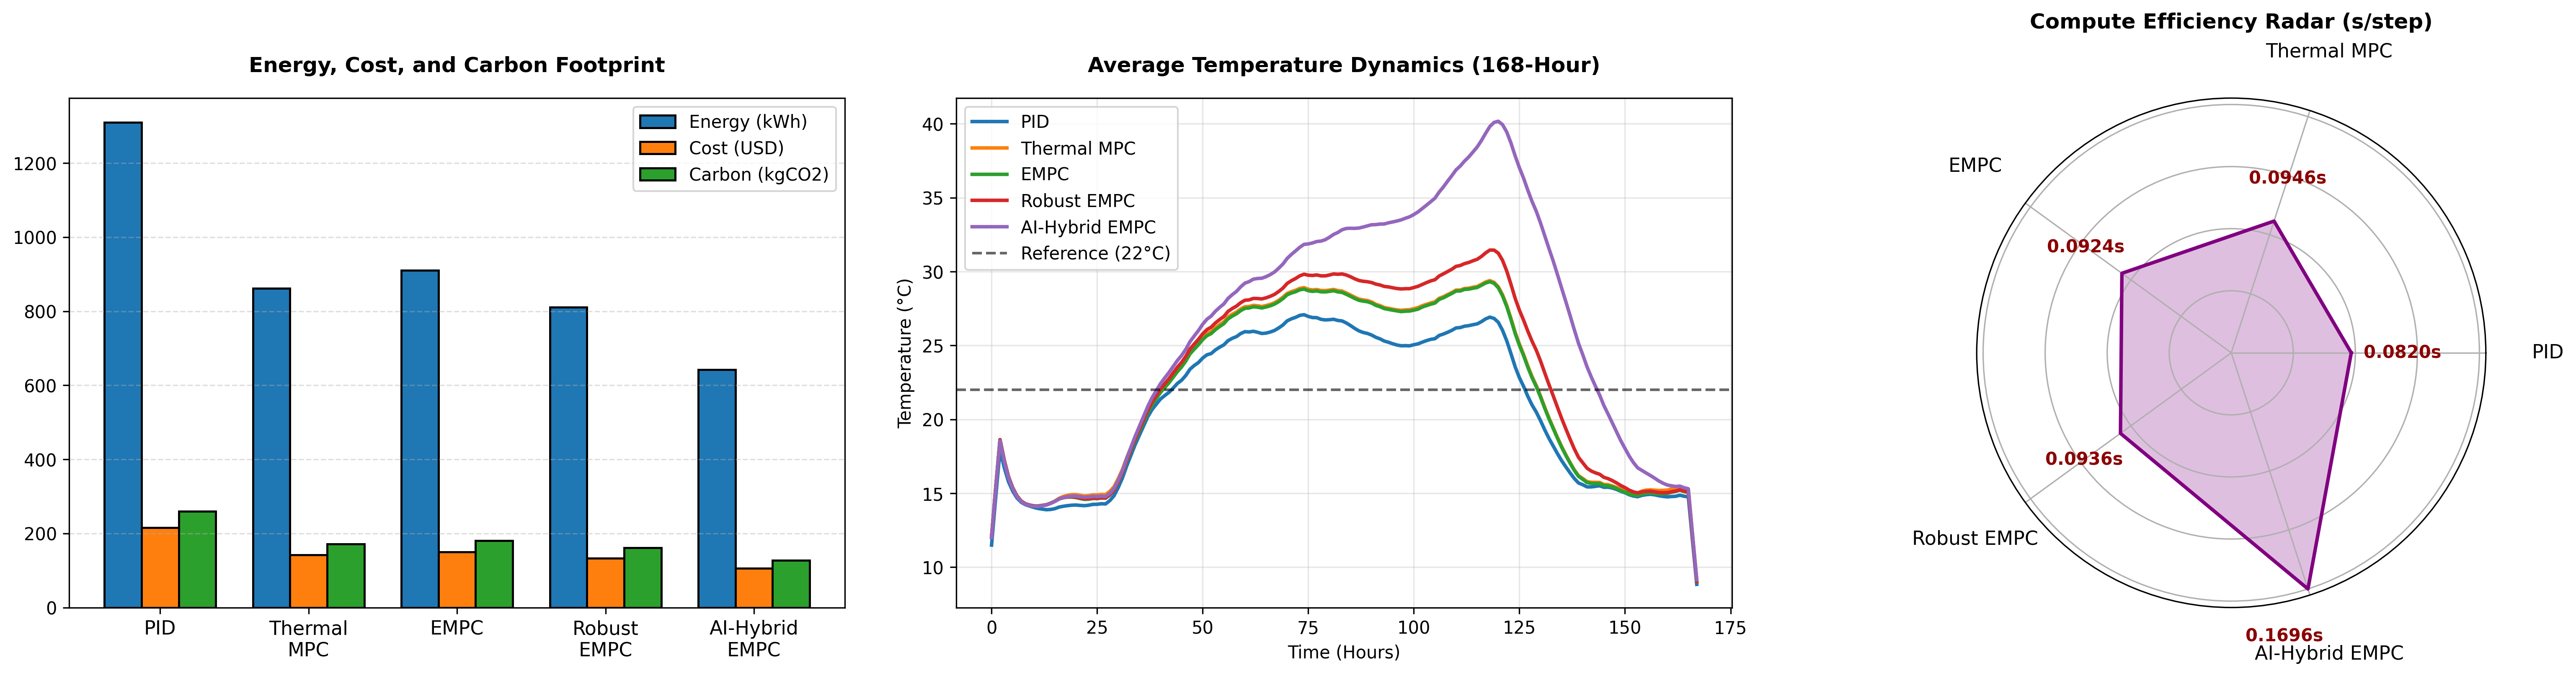

In [23]:
# ============================
# BLOCK 10 — IEEE PUBLICATION DIAGRAMS (FIG 3 & FIG 4)
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# DATA ALIGNMENT (Using the final validated results)
# ------------------------------------------------------------
data = {
    "Sim_Key": ["PID", "MPC", "EMPC", "ROBUST", "HYBRID"],
    "Display_Name": ["PID", "Thermal\nMPC", "EMPC", "Robust\nEMPC", "AI-Hybrid\nEMPC"],
    "Energy": [1309.861, 861.403, 910.164, 810.680, 642.187],
    "Cost": [215.271, 141.557, 149.793, 133.229, 105.661],
    "Carbon": [260.061, 171.012, 180.706, 160.838, 127.800],
    "ComputeTime": [0.0820, 0.0946, 0.0924, 0.0936, 0.1696]
}
df_kpi = pd.DataFrame(data)

keys = df_kpi["Sim_Key"].values
labels = df_kpi["Display_Name"].values
x = np.arange(len(labels))
width = 0.25

# ============================================================
# FIGURE 3: KPI Bar, Temperature Trajectory, and Compute Radar
# ============================================================
fig3 = plt.figure(figsize=(22, 6), dpi=300)

# --- 3A: ENERGY / COST / CARBON BAR PLOT ---
ax1 = plt.subplot(1, 3, 1)
ax1.bar(x - width, df_kpi["Energy"], width, label="Energy (kWh)", edgecolor="black", color="#1f77b4", linewidth=1.2)
ax1.bar(x, df_kpi["Cost"], width, label="Cost (USD)", edgecolor="black", color="#ff7f0e", linewidth=1.2)
ax1.bar(x + width, df_kpi["Carbon"], width, label="Carbon (kgCO2)", edgecolor="black", color="#2ca02c", linewidth=1.2)

ax1.set_title("Energy, Cost, and Carbon Footprint", fontweight="bold", pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(loc="upper right")

# --- 3B: AVERAGE TEMPERATURE TRAJECTORY ---
ax2 = plt.subplot(1, 3, 2)
if "results" in globals() and "PID" in results:
    time_steps = np.arange(len(results["PID"]["trajectory"]))
    for i, key in enumerate(keys):
        if key in results:
            avg_temp = np.mean(results[key]["trajectory"], axis=1)
            smooth = np.convolve(avg_temp, np.ones(5)/5, mode="same")
            ax2.plot(time_steps, smooth, linewidth=2, label=labels[i].replace("\n", " "))
    ax2.axhline(22.0, color="black", linestyle="--", alpha=0.6, label="Reference (22°C)")

ax2.set_title("Average Temperature Dynamics (168-Hour)", fontweight="bold", pad=15)
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("Temperature (°C)")
ax2.grid(alpha=0.3)
ax2.legend()

# --- 3C: COMPUTE EFFICIENCY RADAR ---
ax3 = plt.subplot(1, 3, 3, polar=True)
compute = df_kpi["ComputeTime"].values
compute_norm = compute / (np.max(compute) + 1e-8)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

compute_norm = np.concatenate((compute_norm, [compute_norm[0]]))
angles += angles[:1]

ax3.plot(angles, compute_norm, linewidth=2, color="purple")
ax3.fill(angles, compute_norm, alpha=0.25, color="purple")
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels([l.replace("\n", " ") for l in labels], fontsize=11)
ax3.tick_params(axis='x', pad=25)

for i, (angle, r, val) in enumerate(zip(angles[:-1], compute_norm[:-1], compute)):
    ha = 'center'
    r_offset = 0.18
    if i == 0: ha = 'left'; r_offset = 0.05
    elif i == 4: ha = 'right'; r_offset = 0.20
    ax3.text(angle, r + r_offset, f"{val:.4f}s", ha=ha, va='center', fontsize=10, color="darkred", fontweight="bold")

ax3.set_title("Compute Efficiency Radar (s/step)", pad=40, fontsize=12, fontweight="bold")
ax3.set_rlabel_position(180)
ax3.set_yticks([0.25, 0.5, 0.75, 1.0])
ax3.set_yticklabels([])

plt.tight_layout(pad=3.0)
plt.show()


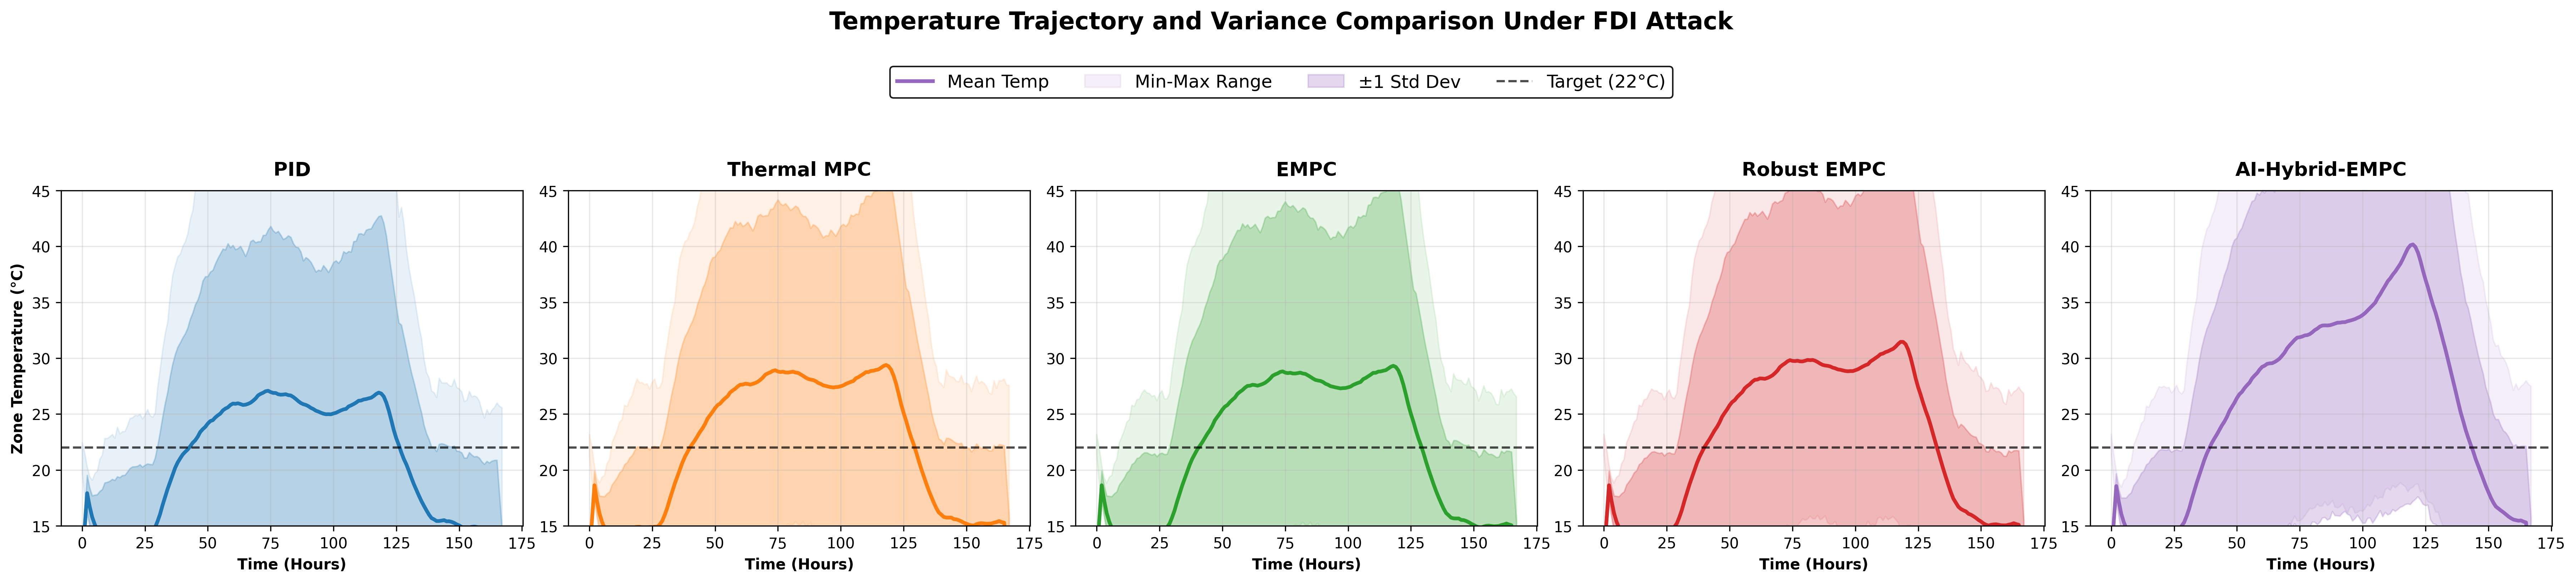

In [40]:
# ============================
# BLOCK 11 — TEMPERATURE VARIANCE & TRAJECTORIES (GLOBAL TOP LEGEND)
# ============================

import numpy as np
import matplotlib.pyplot as plt

# Style map for distinct coloring across the 5 plots
style_map = {
    "PID": "#1f77b4",
    "MPC": "#ff7f0e",
    "EMPC": "#2ca02c",
    "ROBUST": "#d62728",
    "HYBRID": "#9467bd"
}

display_names = {
    "PID": "PID",
    "MPC": "Thermal MPC",
    "EMPC": "EMPC",
    "ROBUST": "Robust EMPC",
    "HYBRID": "AI-Hybrid-EMPC"
}

controllers = ["PID", "MPC", "EMPC", "ROBUST", "HYBRID"]

# 1x5 Horizontal Layout, slightly taller (5.5) to accommodate the global top legend cleanly
fig = plt.figure(figsize=(24, 5.5), dpi=300)

if "results" in globals() and "PID" in results:
    time_steps = np.arange(len(results["PID"]["trajectory"]))

    for i, c in enumerate(controllers):
        if c in results:
            traj = results[c]["trajectory"]  # Shape: (T, zones)

            # Calculate Variance Metrics
            mean_temp = np.mean(traj, axis=1)
            std_temp = np.std(traj, axis=1)
            min_temp = np.min(traj, axis=1)
            max_temp = np.max(traj, axis=1)

            # Smooth the mean for clean visualization
            mean_smooth = np.convolve(mean_temp, np.ones(5)/5, mode="same")

            color = style_map.get(c, "black")

            ax = plt.subplot(1, 5, i + 1)

            # Plot the main smoothed trajectory
            ax.plot(time_steps, mean_smooth, color=color, linewidth=2.5, label="Mean Temp")

            # Plot the Min-Max Envelope (System Range)
            ax.fill_between(time_steps, min_temp, max_temp, color=color, alpha=0.10, label="Min-Max Range")

            # Plot the Standard Deviation Envelope (Variance)
            ax.fill_between(time_steps, mean_smooth - std_temp, mean_smooth + std_temp,
                            color=color, alpha=0.25, label="±1 Std Dev")

            # Reference Line
            ax.axhline(22.0, color="black", linestyle="--", linewidth=1.5, alpha=0.7, label="Target (22°C)")

            # Formatting
            ax.set_title(display_names[c], fontweight="bold", fontsize=13, pad=10)
            ax.set_xlabel("Time (Hours)", fontweight="bold")

            # Only add the Y-axis label to the leftmost plot to keep it clean
            if i == 0:
                ax.set_ylabel("Zone Temperature (°C)", fontweight="bold")

            # Lock the Y-axis limits to 45°C
            ax.set_ylim(15, 45)
            ax.grid(alpha=0.3)

            # Note: The per-plot legend has been removed to prevent overlap

    # Extract the legend handles/labels from the last axis plotted
    handles, labels = ax.get_legend_handles_labels()

    # Place a single global legend perfectly centered above all the subplots
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.90),
               ncol=4, fontsize=12, framealpha=0.9, edgecolor="black")

    # Main Header
    plt.suptitle("Temperature Trajectory and Variance Comparison Under FDI Attack",
                 fontweight="bold", fontsize=16, y=0.98)

    # Compress the layout slightly from the top (0.82) so the plots don't crash into the global legend
    plt.tight_layout(rect=[0, 0, 1, 0.82])
    plt.show()
else:
    print("❌ Error: 'results' dictionary not found. Please run the Block 9 simulation first.")